In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
df = pd.read_csv('../data/raw/mental-health.csv')
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [11]:
df.to_csv('../data/processed/mental_health_processado.csv', index=False)
print('✅ CSV processado salvo em data/processed/')
df.head(3)

✅ CSV processado salvo em data/processed/


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
24,2014-08-27 11:36:48,33,male,United States,CA,No,Yes,Yes,Rarely,26-100,...,Don't know,No,No,Yes,Yes,No,Yes,Don't know,No,Relatively new job. Ask again later
25,2014-08-27 11:37:08,35,male,United States,TN,No,Yes,Yes,Sometimes,More than 1000,...,Very easy,Yes,No,Some of them,Yes,No,Yes,No,No,Sometimes I think about using drugs for my me...
33,2014-08-27 11:39:36,42,male,United States,WA,No,Yes,Yes,Sometimes,26-100,...,Very easy,Maybe,No,Some of them,Some of them,Maybe,Yes,Don't know,No,I selected my current employer based on its po...


In [14]:
print('Gênero')
print(df['Gender'].value_counts())

print('\nFaixa etária')

# Criando faixa etária (não tem nesse dataset)
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-60', '60+']

df['faixa_etaria'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df['faixa_etaria'].value_counts().sort_index())

print('\nTop 10 países')
print(df['Country'].value_counts().head(10))

Gênero
Gender
male                  42
female                18
m                     15
f                      4
woman                  1
female                 1
cis-female/femme       1
female (cis)           1
cis male               1
a little about you     1
p                      1
Name: count, dtype: int64

Faixa etária
faixa_etaria
0-18      1
19-25     6
26-35    41
36-45    30
46-60     7
60+       0
Name: count, dtype: int64

Top 10 países
Country
United States    84
Israel            1
Bahamas, The      1
Name: count, dtype: int64


In [15]:
df = df.rename(columns={
    'Gender': 'genero',
    'Age': 'idade',
    'Country': 'pais'
})

In [16]:
df.columns

Index(['Timestamp', 'idade', 'genero', 'pais', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments', 'faixa_etaria'],
      dtype='str')

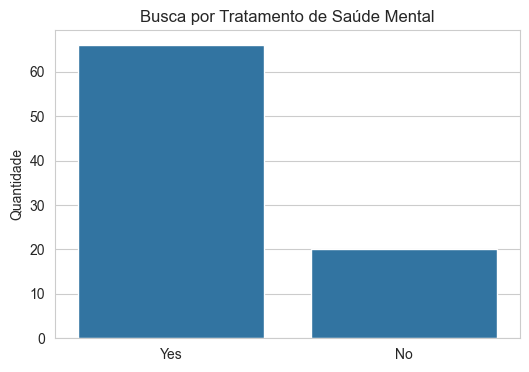

In [ ]:
# Taxa de busca por tratamento

sns.set_style("whitegrid")

plt.figure(figsize=(6,4))

sns.countplot(x='treatment', data=df)

plt.title('Busca por tratamento de saúde mental')
plt.xlabel('')
plt.ylabel('Quantidade')

plt.show()

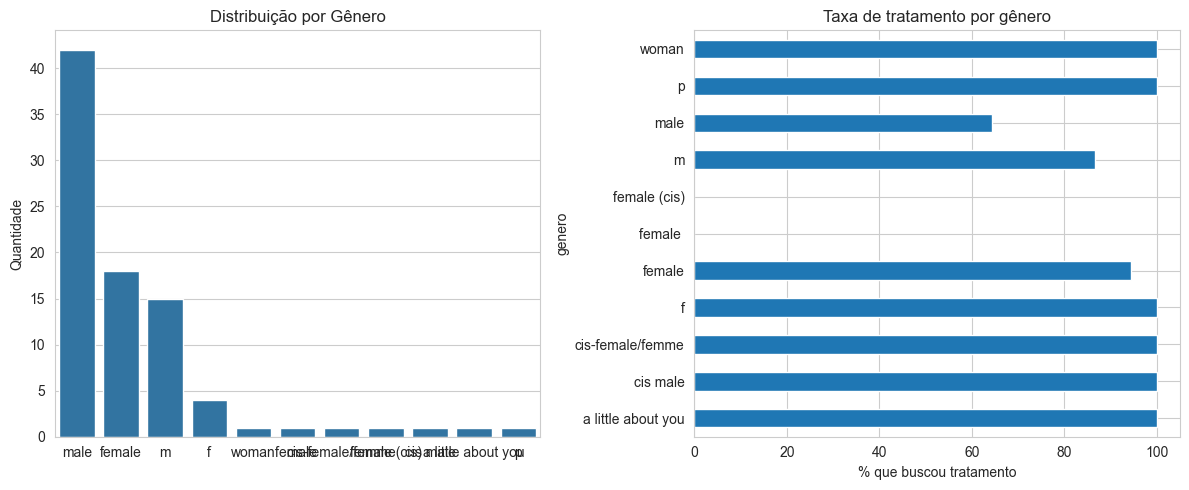

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Distribuição por gênero ──
sns.countplot(x='genero', data=df, ax=axes[0])
axes[0].set_title('Distribuição por gênero')
axes[0].set_xlabel('')
axes[0].set_ylabel('Quantidade')

# ── Taxa de tratamento por gênero ──
taxa = df.groupby('genero')['treatment'].value_counts(normalize=True).unstack() * 100

taxa['Yes'].plot(kind='barh', ax=axes[1])
axes[1].set_title('Taxa de tratamento por gênero')
axes[1].set_xlabel('% que buscou tratamento')

plt.tight_layout()
plt.show()

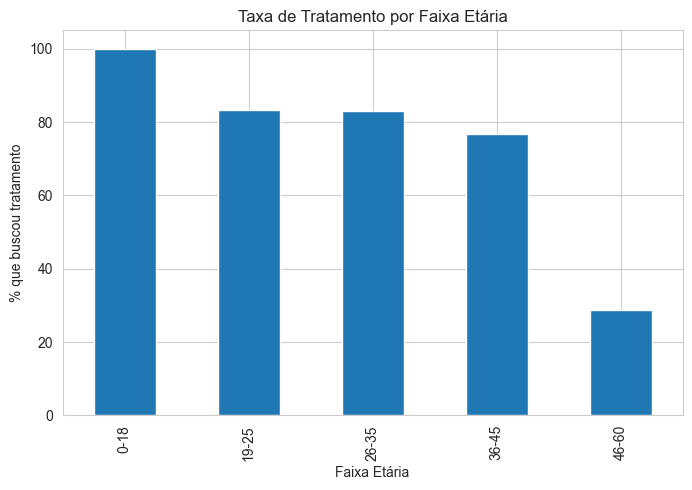

In [ ]:
sns.set_style("whitegrid")

# Taxa de tratamento por faixa etária
taxa = df.groupby('faixa_etaria')['treatment'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,5))

taxa['Yes'].plot(kind='bar')

plt.title('Taxa de tratamento por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('% que buscou tratamento')

plt.show()

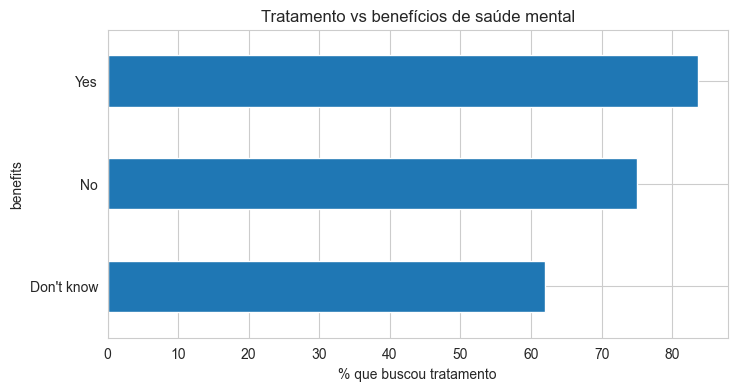

In [23]:
sns.set_style("whitegrid")

taxa = df.groupby('benefits')['treatment'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,4))

taxa['Yes'].plot(kind='barh')

plt.title('Tratamento vs benefícios de saúde mental')
plt.xlabel('% que buscou tratamento')

plt.show()

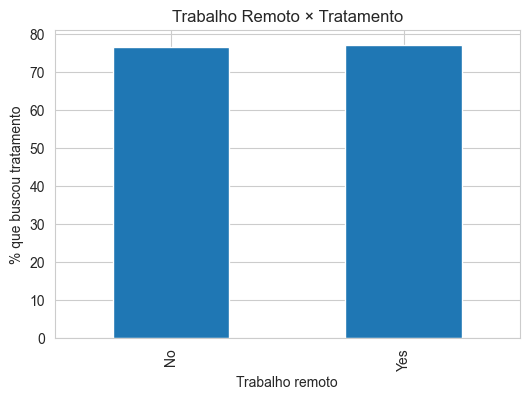

In [ ]:
# Taxa de tratamento por trabalho remoto
taxa = df.groupby('remote_work')['treatment'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(6,4))

taxa['Yes'].plot(kind='bar')

plt.title('Trabalho remoto × Tratamento')
plt.xlabel('Trabalho remoto')
plt.ylabel('% que buscou tratamento')

plt.show()

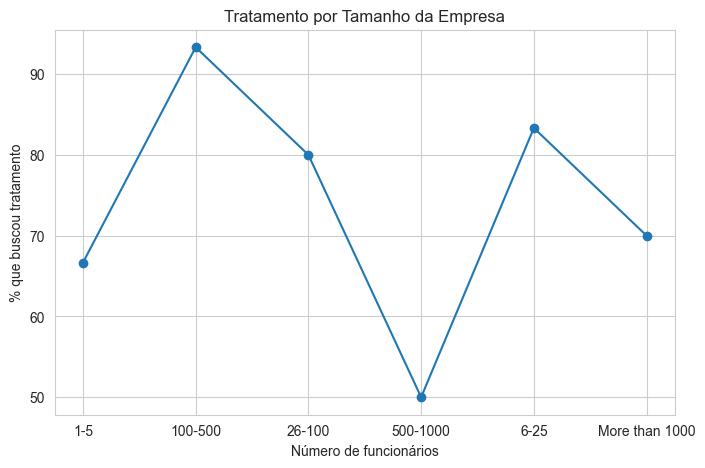

In [25]:
# Taxa de tratamento por tamanho da empresa
taxa = df.groupby('no_employees')['treatment'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(8,5))

taxa['Yes'].plot(marker='o')

plt.title('Tratamento por Tamanho da Empresa')
plt.xlabel('Número de funcionários')
plt.ylabel('% que buscou tratamento')

plt.show()

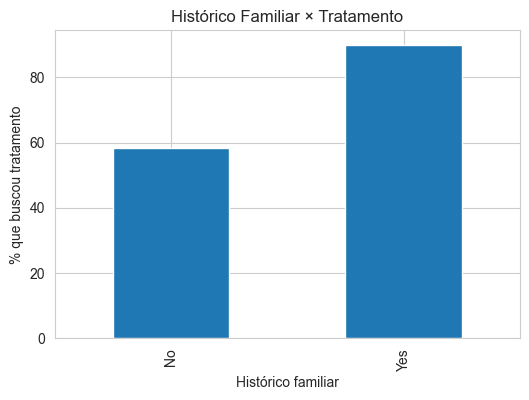

In [ ]:
# Taxa de tratamento por histórico familiar
taxa = df.groupby('family_history')['treatment'].value_counts(normalize=True).unstack() * 100

plt.figure(figsize=(6,4))

taxa['Yes'].plot(kind='bar')

plt.title('Histórico Familiar × Tratamento')
plt.xlabel('Histórico familiar')
plt.ylabel('% que buscou tratamento')

plt.show()

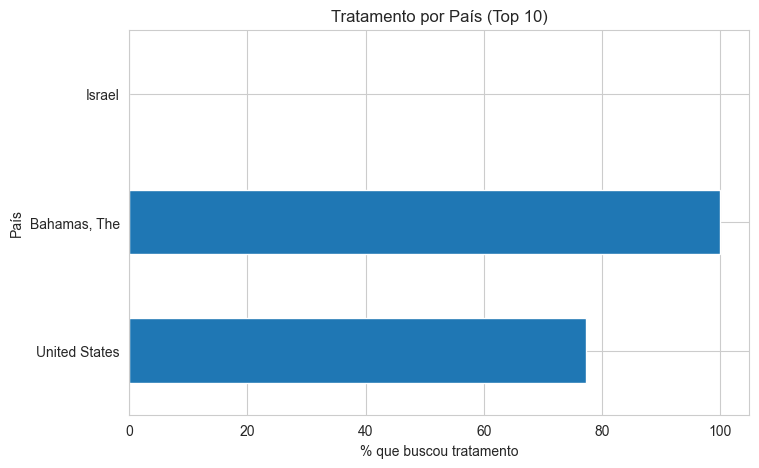

In [31]:
# Top 10 países
top = df['pais'].value_counts().head(10).index

df_top = df[df['pais'].isin(top)]

# Taxa de tratamento
taxa = (
    df_top.groupby('pais')['treatment']
    .value_counts(normalize=True)
    .unstack() * 100
)

# Ordenar (fica mais bonito)
taxa = taxa.sort_values('Yes')

# Gráfico
plt.figure(figsize=(8,5))

taxa['Yes'].plot(kind='barh')

plt.title('Tratamento por País (Top 10)')
plt.xlabel('% que buscou tratamento')
plt.ylabel('País')

plt.show()